In [4]:
%pip install kagglehub

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("larsen0966/student-performance-data-set")

print("Path to dataset files:", path)

Path to dataset files: /home/pyodide/.cache/kagglehub/datasets/larsen0966/student-performance-data-set/versions/2


In [10]:
import pandas as pd
import os

print(os.listdir(path))

['student-por.csv']


In [13]:
df=pd.read_csv(f'{path}/student-por.csv')

In [15]:
print(df.head().to_string())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  reason guardian  traveltime  studytime  failures schoolsup famsup paid activities nursery higher internet romantic  famrel  freetime  goout  Dalc  Walc  health  absences  G1  G2  G3
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  course   mother           2          2         0       yes     no   no         no     yes    yes       no       no       4         3      4     1     1       3         4   0  11  11
1     GP   F   17       U     GT3       T     1     1  at_home     other  course   father           1          2         0        no    yes   no         no      no    yes      yes       no       5         3      3     1     1       3         2   9  11  11
2     GP   F   15       U     LE3       T     1     1  at_home     other   other   mother           1          2         0       yes     no   no         no     yes    yes      yes       no       4         3      2     2     3       

In [65]:
x=df[['studytime', 'failures', 'absences', 'health', 'freetime', 'Medu', 'Fedu']]
y=df['G3']

In [66]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [67]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2)

In [68]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [69]:
model.fit(x_train, y_train)
print(model.score(x_test, y_test))

0.12127838966916515


In [70]:
y_pred=model.predict(x_test)

from sklearn.metrics import r2_score, mean_squared_error

print(r2_score(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.12127838966916515
9.674256971488468


In [71]:
print(y_test[:5])

378    17
323    10
381    15
164    10
575    10
Name: G3, dtype: int64


In [72]:
print(y_pred[:5])

[12.15130888 13.27963028 14.23895522  9.10763789 12.47981671]


In [73]:
#using decision trees
from sklearn.tree import DecisionTreeRegressor
modeltree=DecisionTreeRegressor(max_depth=5)
modeltree.fit(x_train, y_train)
y_pred_tree=modeltree.predict(x_test)
print(r2_score(y_test, y_pred_tree))
print(mean_squared_error(y_test, y_pred_tree))

0.0332000013342042
10.643953121405795


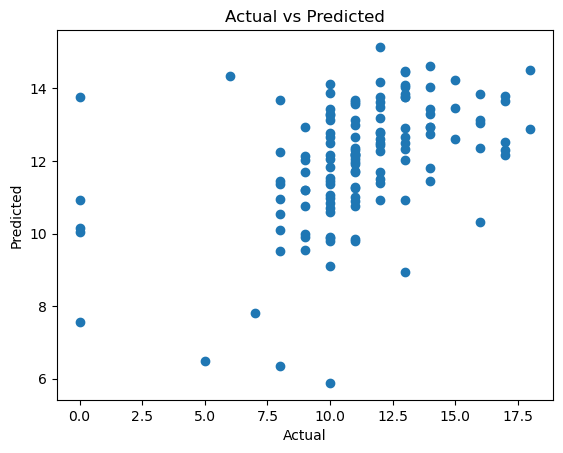

In [74]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

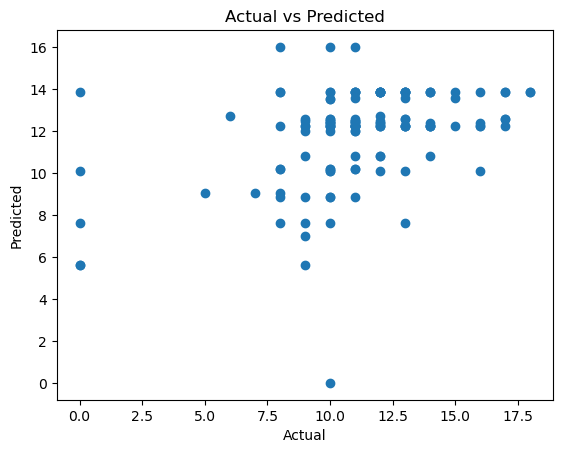

In [75]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_tree)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [76]:
#using decision trees
from sklearn.linear_model import Ridge
modelridge=Ridge()
modelridge.fit(x_train, y_train)
y_pred_ridge=modelridge.predict(x_test)
print(r2_score(y_test, y_pred_ridge))
print(mean_squared_error(y_test, y_pred_ridge))

0.12119609183476876
9.675163026817923


In [78]:
import pickle
with open("linear_model.pkl", "wb") as f:
    pickle.dump(model,f)

with open("decision_tree_model", "wb") as f:
    pickle.dump(modeltree, f)

with open("ridge_model.pkl", "wb") as f:
    pickle.dump(modelridge, f)

In [80]:
!tar chvfz notebook.tar.gz *

<class 'OSError'>: Not available